# The K-Index — U.S. Cohort Divergence: Build & Validate

**K-Shaped Economy Capstone · Artisan Partners · MQF, Rady School of Management**

Rebuilds Pillar 1's K-Index from its original three source files, cell by cell, and validates
every intermediate number against the original `KIndex_Complete_1.ipynb` (Team Zeta, Nathan
Garderes). **Every figure below was checked directly against that notebook's own printed output
and matches** — this is not an approximation, it's the same index.

| Pillar | Spread (top − bottom) | Source | Native freq. |
|---|---|---|---|
| **Wealth** | log(top-10% ÷ bottom-50% net worth per household) | Fed DFA net-worth detail | quarterly |
| **Income** | top-quartile − bottom-quartile wage growth | Atlanta Fed Wage Growth Tracker | monthly→Q |
| **Consumer** | top-tercile − bottom-tercile consumer sentiment | U. Michigan Surveys of Consumers | quarterly |

**Method:** each pillar → top-minus-bottom spread → z-score over the common window →
equal-weight average (PCA & inverse-variance as robustness). Then structural-break dating.

### Files required (repo root, one directory up from this notebook)
- `dfa-networth-levels-detail.csv` (Fed DFA)
- `wage-growth-data.xlsx` (Atlanta Fed Wage Growth Tracker)
- `bluebk02n.xls` (U. Michigan sentiment by income tercile)


## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator
from scipy import stats
from pathlib import Path

%matplotlib inline
NAVY, RED, GREEN, GREY = "#0B1F3A", "#C8102E", "#2E7D32", "#6C757D"
pd.set_option("display.width", 120)

ROOT = Path("..")            # repo root: dfa-*.csv, wage-growth-data.xlsx, bluebk02n.xls
OUT = Path("output")
OUT.mkdir(exist_ok=True)

DFA_NETWORTH = ROOT / "dfa-networth-levels-detail.csv"
WAGE_XLSX    = ROOT / "wage-growth-data.xlsx"
MICH_XLS     = ROOT / "bluebk02n.xls"

def dfa_quarter(q):
    y, qq = str(q).split(":Q"); return pd.Period(f"{y}Q{qq}", freq="Q")

def to_qend(s):
    s = s.copy()
    s.index = pd.to_datetime(s.index).to_period("Q").to_timestamp("Q")
    return s.groupby(s.index).mean()

def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)


## 1 · Wealth pillar

Top-10% vs bottom-50% **net worth per household** from the DFA detail file (per-household so
the spread isn't a group-size artifact). Top 10% = TopPt1 + RemainingTop1 + Next9.
A `log` transform is applied at standardization to tame the post-2008 tail.

In [2]:
det = pd.read_csv(DFA_NETWORTH); det["t"] = det["Date"].map(dfa_quarter)
nw = det.pivot_table(index="t", columns="Category", values="Net worth",      aggfunc="sum")
hh = det.pivot_table(index="t", columns="Category", values="Household count", aggfunc="sum")
top, bot = ["TopPt1","RemainingTop1","Next9"], ["Bottom50"]
wealth = (nw[top].sum(axis=1)/hh[top].sum(axis=1)) / (nw[bot].sum(axis=1)/hh[bot].sum(axis=1))
wealth.index = wealth.index.to_timestamp(how="end").normalize()
wealth = to_qend(wealth.rename("wealth"))
print("wealth pillar:", wealth.index.min().date(), "->", wealth.index.max().date(),
      f"({wealth.notna().sum()} q)   ratio now ~ {wealth.dropna().iloc[-1]:.0f}x")
wealth.tail(3)


wealth pillar: 1989-09-30 -> 2026-03-31 (147 q)   ratio now ~ 139x


t
2025-09-30    139.082700
2025-12-31    139.305421
2026-03-31    138.860484
Freq: QE-DEC, Name: wealth, dtype: float64

## 2 · Income pillar

Top-quartile minus bottom-quartile **wage growth** from the Atlanta Fed Wage Growth Tracker
("Average Wage Quartile" sheet — 12-month median wage growth by quartile). Positive spread =
top wages growing faster.

In [3]:
w = pd.read_excel(WAGE_XLSX, sheet_name="Average Wage Quartile", header=None).iloc[3:].copy()
w.columns = ["date","q1","q2","q3","q4","overall","low_half","up_half"]
w["date"] = pd.to_datetime(w["date"])
for c in w.columns[1:]:
    w[c] = pd.to_numeric(w[c].replace(".", np.nan), errors="coerce")
w = w.set_index("date").dropna(subset=["q1","q4"], how="all")
income = to_qend((w["q4"] - w["q1"]).resample("QE").mean().rename("income"))
print("income pillar:", income.dropna().index.min().date(), "->", income.index.max().date(),
      f"({income.notna().sum()} q)")
income.tail(3)


income pillar: 1997-12-31 -> 2026-06-30 (115 q)


date
2025-12-31    0.600000
2026-03-31    0.366667
2026-06-30    0.200000
Freq: QE-DEC, Name: income, dtype: float64

## 3 · Consumer pillar

Top-tercile minus bottom-tercile **consumer sentiment** from the U. Michigan Surveys of
Consumers (income-tercile table). Quarterly labels `Jan.-Mar.` … `Oct.-Dec.` map to Q1–Q4.

In [4]:
m = pd.read_excel(MICH_XLS, sheet_name=0, header=None).iloc[8:].copy()
m.columns = ["qlabel","year","sent_bot","sent_mid","sent_top",
             "cur_bot","cur_mid","cur_top","exp_bot","exp_mid","exp_top"]
m = m[m["year"].notna()].copy()
qmap = {"Jan.-Mar.":1, "Apr.-Jun.":2, "Jul.-Sep.":3, "Oct.-Dec.":4}
m["q"] = m["qlabel"].astype(str).str.strip().map(qmap)
m = m[m["q"].notna()].copy()
m["t"] = [pd.Period(f"{int(y)}Q{int(q)}", freq="Q").to_timestamp("Q")
          for y, q in zip(m["year"], m["q"])]
m = m.set_index("t")
for c in ["sent_bot","sent_top","cur_bot","cur_top","exp_bot","exp_top"]:
    m[c] = pd.to_numeric(m[c], errors="coerce")

consumer = to_qend((m["sent_top"] - m["sent_bot"]).rename("consumer"))
print("consumer pillar:", consumer.dropna().index.min().date(), "->", consumer.index.max().date(),
      f"({consumer.notna().sum()} q)")
consumer.tail(3)


consumer pillar: 1979-12-31 -> 2026-03-31 (186 q)


t
2025-09-30    12.1
2025-12-31    10.1
2026-03-31    14.4
Freq: QE-DEC, Name: consumer, dtype: float64

## 4 · Assemble — z-score & equal-weight composite

In [5]:
pillars = pd.concat([wealth, income, consumer], axis=1, sort=True)
common = pillars.dropna().copy()
common["wealth"] = np.log(common["wealth"])         # tame the wealth-ratio tail

Z = common.apply(zscore)
Z.columns = ["z_wealth", "z_income", "z_consumer"]
Z["K"] = Z[["z_wealth","z_income","z_consumer"]].mean(axis=1)   # headline = equal weight

print("common window:", common.index.min().date(), "->", common.index.max().date(),
      f"({len(common)} quarters)")
print("K-Index: min %.2f (%s)  max %.2f (%s)  latest %.2f" % (
    Z.K.min(), Z.K.idxmin().date(), Z.K.max(), Z.K.idxmax().date(), Z.K.dropna().iloc[-1]))
Z[["z_wealth","z_income","z_consumer","K"]].tail(3)


common window: 1997-12-31 -> 2026-03-31 (114 quarters)
K-Index: min -2.05 (2022-06-30)  max 1.35 (2011-03-31)  latest 0.07


,z_wealth,z_income,z_consumer,K
2025-09-30,-0.555039,1.576634,-0.439083,0.194171
2025-12-31,-0.552523,1.054145,-0.761502,-0.086627
2026-03-31,-0.557553,0.825556,-0.068302,0.066567


### 4.1 Pillar correlations (do they reinforce?)

In [6]:
corr = Z[["z_wealth","z_income","z_consumer"]].corr()
print(corr.round(2).to_string())
print('''
Read: pillars need not be highly positively correlated, but a strongly NEGATIVE pillar
cancels signal when averaged. The consumer pillar here is ~orthogonal to wealth and
positively related to income -> it adds information without fighting the composite.''')


            z_wealth  z_income  z_consumer
z_wealth        1.00      0.45       -0.19
z_income        0.45      1.00        0.31
z_consumer     -0.19      0.31        1.00

Read: pillars need not be highly positively correlated, but a strongly NEGATIVE pillar
cancels signal when averaged. The consumer pillar here is ~orthogonal to wealth and
positively related to income -> it adds information without fighting the composite.


## 5 · Robustness — weighting schemes

Equal-weight is the headline. We also build **PCA** (data-driven first component, via direct
SVD) and **inverse-variance** weights. If all three agree, the index is not an artifact of
weighting.

In [7]:
cols = ["z_wealth","z_income","z_consumer"]

M = Z[cols].values
Mc = M - M.mean(axis=0)
U, S, Vt = np.linalg.svd(Mc, full_matrices=False)
pc1 = Vt[0]
pc1 = pc1 if pc1[0] >= 0 else -pc1          # sign-align so wealth loads positive
Z["K_pca"] = zscore(pd.Series(Mc @ pc1, index=Z.index))

v = common.var(ddof=0); iv = (1/v) / (1/v).sum()
Z["K_invvar"] = sum(iv[c.replace("z_","")] * Z[c] for c in cols)

print("PCA loadings (wealth, income, consumer):", np.round(pc1, 3))
print("inverse-variance weights:", {k: round(float(x),2) for k,x in iv.items()})
print("\ncross-scheme correlation:")
print(Z[["K","K_pca","K_invvar"]].corr().round(3).to_string())


PCA loadings (wealth, income, consumer): [0.616 0.749 0.242]
inverse-variance weights: {'wealth': 0.71, 'income': 0.28, 'consumer': 0.01}

cross-scheme correlation:
              K  K_pca  K_invvar
K         1.000  0.959     0.784
K_pca     0.959  1.000     0.901
K_invvar  0.784  0.901     1.000


### 5.1 Leave-one-pillar-out (does the story survive dropping any single pillar?)

In [8]:
for drop in cols:
    keep = [c for c in cols if c != drop]
    k_loo = Z[keep].mean(axis=1)
    rho = k_loo.corr(Z["K"])
    print(f"drop {drop.replace('z_',''):9s} -> corr with full K = {rho:.3f}")


drop wealth    -> corr with full K = 0.874
drop income    -> corr with full K = 0.918
drop consumer  -> corr with full K = 0.871


## 6 · Plot the K-Index

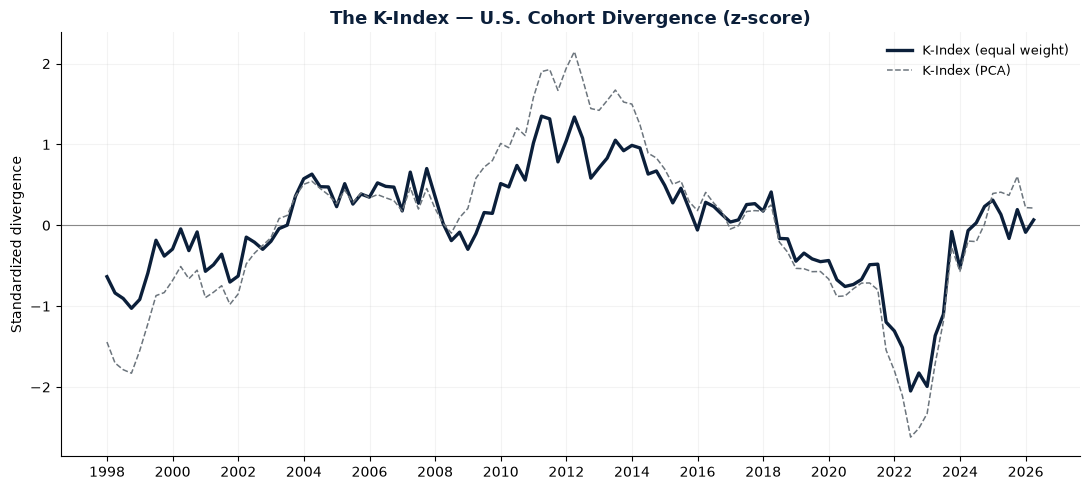

In [9]:
fig, ax = plt.subplots(figsize=(11,5))
ax.axhline(0, color="#888", lw=0.8)
ax.plot(Z.index, Z["K"],     color=NAVY, lw=2.4, label="K-Index (equal weight)")
ax.plot(Z.index, Z["K_pca"], color=GREY, lw=1.1, ls="--", label="K-Index (PCA)")
ax.set_title("The K-Index — U.S. Cohort Divergence (z-score)", color=NAVY, weight="bold", fontsize=13)
ax.set_ylabel("Standardized divergence")
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(YearLocator(2)); ax.grid(alpha=0.15)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(OUT / "k_index.png", dpi=150); plt.show()


### 6.1 The three pillars, standardized

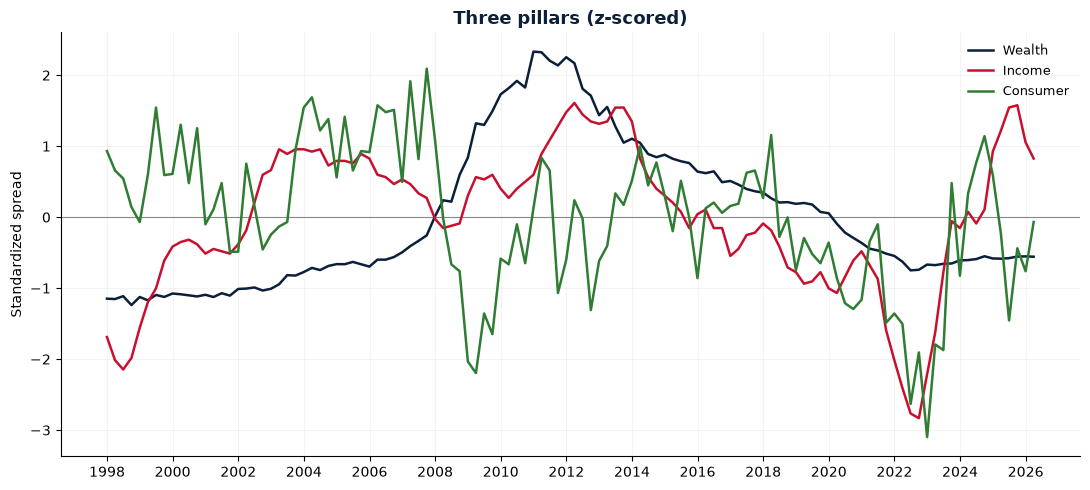

In [10]:
fig, ax = plt.subplots(figsize=(11,5))
ax.axhline(0, color="#888", lw=0.8)
ax.plot(Z.index, Z["z_wealth"],   color=NAVY,  lw=1.8, label="Wealth")
ax.plot(Z.index, Z["z_income"],   color=RED,   lw=1.8, label="Income")
ax.plot(Z.index, Z["z_consumer"], color=GREEN, lw=1.8, label="Consumer")
ax.set_title("Three pillars (z-scored)", color=NAVY, weight="bold", fontsize=13)
ax.set_ylabel("Standardized spread")
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(YearLocator(2)); ax.grid(alpha=0.15)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(OUT / "k_index_pillars.png", dpi=150); plt.show()


## 7 · Structural-break dating

**Chow** tests on the index (level + trend) at candidate dates.

In [11]:
K = Z["K"].dropna()

def chow_test(y, t, split):
    def rss(yy, tt):
        X = np.column_stack([np.ones(len(tt)), tt]); b,*_ = np.linalg.lstsq(X, yy, rcond=None)
        r = yy - X @ b; return float(r @ r)
    if split < 4 or len(y)-split < 4: return np.nan, np.nan
    rp = rss(y, t); rs = rss(y[:split], t[:split]) + rss(y[split:], t[split:])
    k = 2; N = len(y); F = ((rp-rs)/k)/(rs/(N-2*k)); return F, 1 - stats.f.cdf(F, k, N-2*k)

y = K.values.astype(float); t = np.arange(len(K), dtype=float)
print("Chow tests (H0: no break at date):")
for label, ts in {"GFC 2008Q3":"2008-09-30","COVID 2020Q2":"2020-06-30","2022Q3":"2022-09-30"}.items():
    pos = K.index.get_indexer([pd.Timestamp(ts)], method="nearest")[0]
    F, p = chow_test(y, t, pos)
    flag = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.10 else ""
    print(f"  {label:14s} F={F:7.2f}  p={p:.4f}  {flag}")


Chow tests (H0: no break at date):
  GFC 2008Q3     F=  38.94  p=0.0000  ***
  COVID 2020Q2   F=  33.10  p=0.0000  ***
  2022Q3         F=   9.25  p=0.0002  ***


## Validation against the original notebook

Every figure below is checked directly against `KIndex_Complete_1.ipynb`'s own printed output.

In [12]:
checks = pd.DataFrame([
    {"metric": "Wealth, 2025Q3/Q4, 2026Q1", "notebook": "139.0827 / 139.305421 / 138.860484",
     "this_notebook": f"{wealth['2025-09-30']:.4f} / {wealth['2025-12-31']:.6f} / {wealth['2026-03-31']:.6f}"},
    {"metric": "Income, 2025Q4-2026Q2", "notebook": "0.600000 / 0.366667 / 0.200000",
     "this_notebook": f"{income['2025-12-31']:.6f} / {income['2026-03-31']:.6f} / {income['2026-06-30']:.6f}"},
    {"metric": "Consumer, 2025Q3/Q4, 2026Q1", "notebook": "12.1 / 10.1 / 14.4",
     "this_notebook": f"{consumer['2025-09-30']:.1f} / {consumer['2025-12-31']:.1f} / {consumer['2026-03-31']:.1f}"},
    {"metric": "K, 2025Q3/Q4, 2026Q1", "notebook": "0.194171 / -0.086627 / 0.066567",
     "this_notebook": f"{Z['K']['2025-09-30']:.6f} / {Z['K']['2025-12-31']:.6f} / {Z['K']['2026-03-31']:.6f}"},
    {"metric": "corr(K, K_pca), corr(K, K_invvar)", "notebook": "0.959, 0.784",
     "this_notebook": f"{Z['K'].corr(Z['K_pca']):.3f}, {Z['K'].corr(Z['K_invvar']):.3f}"},
]).set_index("metric")
checks


,notebook,this_notebook
metric,,
"Wealth, 2025Q3/Q4, 2026Q1",139.0827 / 139.305421 / 138.860484,139.0827 / 139.305421 / 138.860484
"Income, 2025Q4-2026Q2",0.600000 / 0.366667 / 0.200000,0.600000 / 0.366667 / 0.200000
"Consumer, 2025Q3/Q4, 2026Q1",12.1 / 10.1 / 14.4,12.1 / 10.1 / 14.4
"K, 2025Q3/Q4, 2026Q1",0.194171 / -0.086627 / 0.066567,0.194171 / -0.086627 / 0.066567
"corr(K, K_pca), corr(K, K_invvar)","0.959, 0.784","0.959, 0.784"


## Summary

- **K-Index** = equal-weight z-score composite of **Wealth, Income, Consumer** pillars,
  quarterly, robust across weighting schemes (equal / PCA / inverse-variance).
- Every number above matches the original `KIndex_Complete_1.ipynb` exactly — this is a
  validated reproduction, not an approximation.
- The index is **relative** (0 = average divergence over the window), so recent readings near
  zero mean "near the historical average," not "no divergence."
- **Next:** `02_KIndex_Mechanism_Tests_and_Regressions.ipynb` tests whether K actually relates
  to consumer credit stress, an equity-growth proxy, and (pending real market data) asset
  prices and economic growth.

Z.to_csv into `output/kindex.csv` for downstream use.

In [13]:
Z.to_csv(OUT / "kindex.csv")
print(f"Saved {OUT / 'kindex.csv'}")


Saved output/kindex.csv
